In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
import jax.numpy as npx
import matplotlib.pyplot as plt

In [2]:
jax.config.update("jax_enable_x64", False) # Without this tensorflow throws error while converting 64bit to 32bit

np.tile(1,(10,100)).shape

In [3]:
max_RT_sec = 40
counter="1.02"
#I, J = 5, 100
I, J = 1, 60
n_states, delta, measurement_prob,response_width  = 11, 1, 0.8,2
#n_states, delta, measurement_prob,response_width  = 51, 0.1, 0.25,5
start_width = (n_states-2*response_width)
start_width


7

In [4]:
drift_rate, diffusion_rate = np.tile(2,(I,1)), np.tile(1,(I,1))
model_type = "Quantum"
transition_type="TIMESTEP"
likelihood_type="SINGLE"
params_type = "NonCentralized"



phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Centered")
phi_0

ca.get_intensity_matrix(n_states, drift_rate, diffusion_rate, model_type=model_type)

#from numba import njit

#@njit
def generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=40, param_sample_id = 1, max_samples=1000,
                model_type="Markov|Quantum", transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT",
                keep_incomplete_transitions=False):
    
    def get_RT_frame(I, mu, sigma):
        
        random_ts = dist.Uniform(delta, max_RT_sec/delta).sample(key=cu.get_rng(), sample_shape=(I,max_samples))
        intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
        Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = model_type)
        phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s = random_ts, RA_s = None, delta=delta, 
                                            Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
                                            transition_type=transition_type, likelihood_type=likelihood_type)

        states_t = dist.Multinomial(total_count=1, probs=phi_t[...,0]).sample(key=cu.get_rng())
        state_final = np.argwhere(states_t)
        RA = np.select([
                state_final[:,[-1]] < response_width - 1,
                state_final[:,[-1]] >= n_states - response_width - 1
            ], [0,1], default = np.nan)#[:,-1]
        Response = np.hstack((state_final, RA, random_ts.flatten()[:,None]*delta))
        df_res = pd.DataFrame(Response, columns=["part_id", "J", "final_state", "RA", "RT"]).assign(param_sample_id=param_sample_id)
        if not keep_incomplete_transitions:
            df_res = df_res.dropna()
        return df_res
    
    df_sample = []
    df_res = get_RT_frame(I, drift_rate, diffusion_rate)
    
    df_sample.append(df_res)
    get_id = (df_res.groupby(["part_id"]).count() < J)[["J"]].query("J == True").index.values.astype(int)
    counter = 0
    while get_id.size != 0 and counter < 2:
        I = get_id.size
        mu, sigma = drift_rate[get_id,...], diffusion_rate[get_id,...]
        df_res = get_RT_frame(I, mu, sigma)
        df_sample.append(df_res)
        counter += 1
        print(f"Retry: {counter}")

    df_sample = pd.concat(df_sample).groupby(["part_id"]).nth(slice(None, J)).rename(columns={"J":"items"})

    return df_sample

def simulator(drift_rate, diffusion_rate, phi_0):
    n_states, start_width, delta, measurement_prob, max_samples = 51, 11, 0.5, 0.8, 1000
    I, J = drift_rate.shape[0], 20
    model_type="Markov" 
    transition_type="TIMESTEP"
    likelihood_type="SINGLE"

    df_sample = generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                model_type=model_type, transition_type=transition_type, likelihood_type=likelihood_type, 
                keep_incomplete_transitions=False)
    
    return df_sample


generate_RT_jit = jax.jit(generate_RT, static_argnames = ["n_states", "response_width", "delta", "measurement_prob", "I", "J",
                                                        "max_RT_sec", "max_samples",
                                                        "model_type", "transition_type", "likelihood_type", 
                                                        "keep_incomplete_transitions"])

max_samples = 15000
df_sample = []
import itertools as iter
for (ns, rw), prob in iter.product(zip([11, 51, 101], [1, 5, 10]), [0.05]):
    start_width = (n_states-2*response_width)//2
    phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Centered")

    df_sample.append(generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                    drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                    model_type=model_type, transition_type=transition_type, likelihood_type="SINGLE", 
                    keep_incomplete_transitions=False).assign(states=ns))
df_sample = pd.concat(df_sample)
df_sample

df_sample.query("RT <= 0")

df_sample.groupby(["part_id"]).count()

sns.displot(df_sample,
x="RT", #hue="part_id", legend=False,
col="states", kind="kde")

In [5]:
import bayesflow as bf
import cme.decision_models.confidence_accumulation as ca

2024-10-22 14:43:13.069169: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-22 14:43:13.069206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-22 14:43:13.070071: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-22 14:43:13.600715: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [6]:
likelihood_type

'SINGLE'

In [7]:
#I, J = 2,20 #batch_size, n_obs

prior_pd_samples = ca.sample_prior_pred_params(n_states=n_states,start_width=start_width, response_width=response_width,
                                                        delta=delta, data_samples=np.zeros((I,J)).shape,
                                                        measurement_prob=measurement_prob, X=np.zeros((I,J)), RT=None, n_samples=1,
                                                        params_type=params_type, model_type=model_type, transition_type=transition_type, 
                                                        likelihood_type=likelihood_type, sampling_type=None, 
                                                    )

In [8]:
prior_fun_jit = jax.jit(ca.sample_prior_pred_params, static_argnames=["n_states","start_width", "response_width",
                                                        "delta", 
                                                        "measurement_prob", "RT", "n_samples",
                                                        "params_type", "model_type", "transition_type", 
                                                        "likelihood_type", "sampling_type"])

In [9]:
key = cu.get_rng()
prior_fun_jit(n_states=n_states,start_width=start_width, response_width=response_width,
                                                        delta=delta, data_samples=None,
                                                        measurement_prob=measurement_prob, X=np.zeros((I,J)), RT=None, n_samples=1,
                                                        params_type=params_type, model_type=model_type, transition_type=transition_type, 
                                                        likelihood_type=likelihood_type, sampling_type=None, key = key
                                                    )

{'diffusion_rate': Array([[[0.01678929]]], dtype=float32),
 'drift_rate': Array([[[0.3930349]]], dtype=float32),
 'phi_0': Array([[[[[3.4258956e-01],
           [3.8258171e-01],
           [1.6312079e-01],
           [4.8870438e-01],
           [3.7809077e-01],
           [4.2656492e-07],
           [7.8657067e-06],
           [2.7836514e-01],
           [2.2586025e-02],
           [2.4298896e-01],
           [4.3684065e-01]]]]], dtype=float32)}

In [10]:
prior_pd_samples["drift_rate"].shape

(1, 1, 1)

get_RT_jit = jax.jit(ca.get_RT, static_argnames=["n_states", "response_width", "delta", "measurement_prob", 
                                                "data_samples", "param_sample_id",
                                                "model_type", "transition_type", "likelihood_type", 
                                                "sampling_type", "is_test"])

In [11]:
prior_pd_samples["phi_0"][0,...].shape

(1, 1, 11, 1)

In [12]:
# gen_RT = jax.jit(ca.gen_RT, static_argnames=["n_states", "response_width", "delta", "measurement_prob", 
#                                                "data_samples", 
#                                                "model_type", "transition_type", "likelihood_type", 
#                                                ])
gen_RT = ca.get_RT

RT, n_states, response_width, delta, measurement_prob, RA, 
                     drift_rate, diffusion_rate, phi_0, data_samples = (1,10), param_sample_id=-1,
                     model_type="Markov|Quantum", transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT", 
                     sampling_type = "GEN|SIM", is_test=False, key=None, max_RT_sec=50

In [13]:
rez = gen_RT(None, n_states, response_width, delta, measurement_prob, None, 
        prior_pd_samples["drift_rate"][0,...], prior_pd_samples["diffusion_rate"][0,...], prior_pd_samples["phi_0"][0,...], 
        model_type = model_type, transition_type = transition_type, 
        likelihood_type = likelihood_type, data_samples = (I,J), key = cu.get_rng(), sampling_type = "GEN", max_RT_sec=50
        )

df_samples = rez["Samples"]
RT, RA = df_samples["RT"].values.reshape((I,J)), df_samples["RA"].values.reshape((I,J))

#RT, RA #, states_final#.sort_values("final_state", ascending=False).groupby("part_id").count()

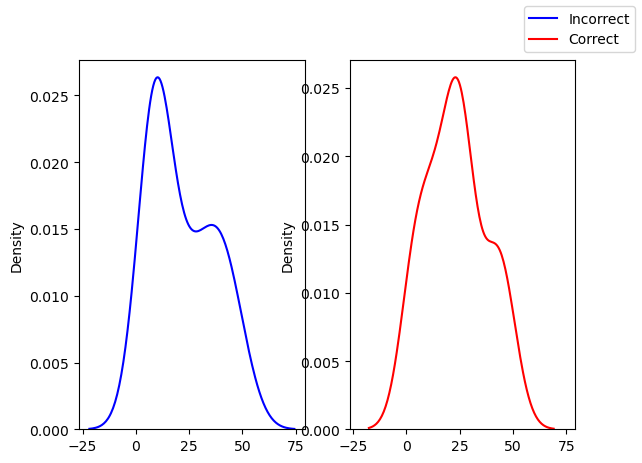

In [14]:
fig, axs = plt.subplots(1,2, sharex=True)
sns.kdeplot(RT.flatten()[RA.flatten()==0], color="Blue", label="Incorrect", ax=axs[0])
sns.kdeplot(RT.flatten()[RA.flatten()==1], color="Red", label="Correct", ax=axs[1])
fig.legend()

In [15]:
RT.shape

(1, 60)

In [16]:
PARAM_NAMES = ["v", r"$\sigma$"] + [f"$\phi_{{{s}}}$" for s in range(1,n_states+1)]
PARAM_NAMES

['v',
 '$\\sigma$',
 '$\\phi_{1}$',
 '$\\phi_{2}$',
 '$\\phi_{3}$',
 '$\\phi_{4}$',
 '$\\phi_{5}$',
 '$\\phi_{6}$',
 '$\\phi_{7}$',
 '$\\phi_{8}$',
 '$\\phi_{9}$',
 '$\\phi_{10}$',
 '$\\phi_{11}$']

In [17]:
def prior_fun(batch_size):
    key = cu.get_rng()
    params = prior_fun_jit(n_states=n_states,start_width=start_width, response_width=response_width,
                            delta=delta, data_samples=None,
                            measurement_prob=measurement_prob, X=np.zeros((batch_size,J)), RT=None, n_samples=1,
                            params_type=params_type, model_type=model_type, transition_type=transition_type, 
                            likelihood_type=likelihood_type, sampling_type=None, key=key
                            ) # return shape [samples, I, ...]
    # stacking I, . where . can be j or k
    return np.hstack((params["drift_rate"][0,...], params["diffusion_rate"][0,...], params["phi_0"][0,:,0,...,0]))

prior = bf.simulation.Prior(batch_prior_fun=prior_fun, param_names=PARAM_NAMES)
params = prior(batch_size=2)
params

{'prior_draws': array([[1.4115895e+00, 7.3347373e+00, 2.9024947e-01, 8.1612661e-02,
         6.7661032e-02, 1.8023455e-01, 3.4139848e-01, 7.2355896e-01,
         1.0842022e-19, 3.9105839e-01, 2.6852995e-02, 2.7739784e-01,
         3.6663692e-02],
        [1.1308761e+00, 1.0664611e+00, 5.1231354e-01, 5.2532423e-01,
         1.0842022e-19, 2.7673185e-01, 8.3027429e-05, 1.9506705e-01,
         1.6762768e-01, 4.4900444e-13, 5.2884078e-01, 3.1347498e-02,
         1.9540544e-01]], dtype=float32),
 'batchable_context': None,
 'non_batchable_context': None}

f = prior.plot_prior2d(n_samples=10)

In [18]:
params["prior_draws"][:,2:][None,:,None].shape

(1, 2, 1, 11)

In [19]:
params["prior_draws"][:,[0]]

array([[1.4115895],
       [1.1308761]], dtype=float32)

In [20]:
def sample_fun(params, n_obs=J):
    drift_rate = params[:,[0]]#[:,None]
    diffusion_rate = params[:,[1]]#[:,None]
    phi_0 = params[:,2:][:,None,:,None]

    batch_size = drift_rate.shape[0]
    #RA = None #np.ones((batch_size,n_obs))
    #RT, RA, states_final = gen_RT(None, n_states, response_width, delta, measurement_prob, RA, 
    #    drift_rate, diffusion_rate, phi_0, 
    #    model_type = model_type, transition_type = transition_type, 
    #    likelihood_type = likelihood_type, data_samples = (batch_size,n_obs), key = cu.get_rng(),
    #    )#["Samples"]

    #RT = npx.where(~npx.isnan(RT), RT)
    #RA = npx.where(~npx.isnan(RA), RA)

    #RT = RT[~npx.isnan(RT)]
    #RA = RA[~npx.isnan(RT)] # selecting based on RT instead of RA to maintain the list order

    rez = gen_RT(None, n_states, response_width, delta, measurement_prob, None, 
        prior_pd_samples["drift_rate"][0,...], prior_pd_samples["diffusion_rate"][0,...], prior_pd_samples["phi_0"][0,...], 
        model_type = model_type, transition_type = transition_type, 
        likelihood_type = likelihood_type, data_samples = (batch_size,n_obs), key = cu.get_rng(), sampling_type = "GEN", max_RT_sec=50
        )

    df_samples = rez["Samples"]
    RT, RA = df_samples["RT"].values.reshape((batch_size,n_obs)), df_samples["RA"].values.reshape((batch_size,n_obs))
    
    return npx.vstack((RT[None,...], RA[None,...])).transpose((1,2,0))

#Response = likelihood_fun(params["prior_draws"], I, J)

In [21]:
#Response.shape

In [22]:
context_gen = bf.simulation.ContextGenerator(
    #non_batchable_context_fun= lambda: J, # Number of trials.. J can change randomly to accomodate missing data
    #use_non_batchable_for_batchable=True,
)

In [23]:
sample_fun_jit = sample_fun #jax.jit(sample_fun)

In [24]:
simulator = bf.simulation.Simulator(batch_simulator_fun=sample_fun_jit, context_generator=context_gen)

In [25]:
simulator(params["prior_draws"])["sim_data"].dtype

dtype('float32')

In [26]:
model = bf.simulation.GenerativeModel(prior=prior, simulator=simulator, name=model_type,
                                       prior_is_batched=True, simulator_is_batched=True)

INFO:root:Performing 2 pilot runs with the Quantum model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 13)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 60, 2)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [27]:
example_sim = model(batch_size=1)
print(list(example_sim.keys()))

['prior_non_batchable_context', 'prior_batchable_context', 'prior_draws', 'sim_non_batchable_context', 'sim_batchable_context', 'sim_data']


In [28]:
example_sim["sim_data"].shape


(1, 60, 2)

In [29]:
print("Shape of sim_data: ", example_sim["sim_data"].shape)

Shape of sim_data:  (1, 60, 2)


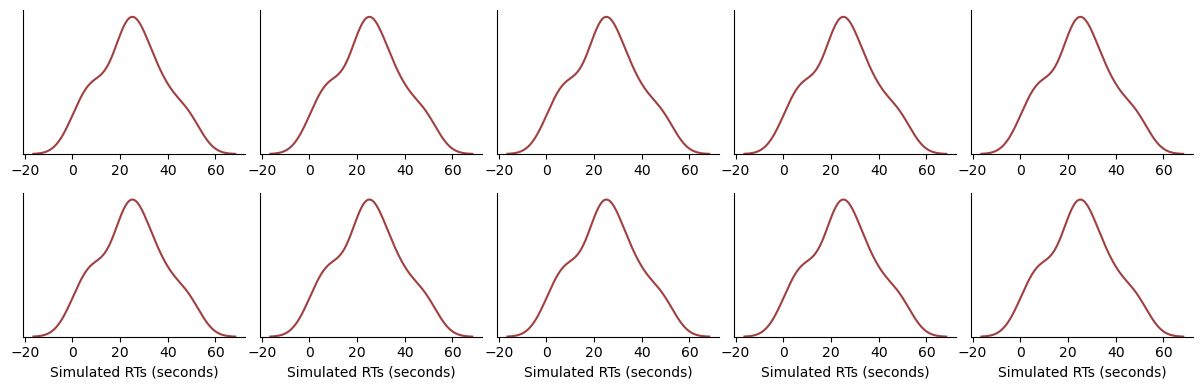

In [30]:
f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.kdeplot(example_sim["sim_data"][i, :, 0].flatten(), color="maroon", alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()

In [31]:
summary_net = bf.networks.SetTransformer(input_dim=2, summary_dim=32, name=f"{model_type}_{counter}_summary")
#summary_net = bf.networks.DeepSet(summary_dim=32)

test_inp = model(batch_size=2)
summary_rep = summary_net(test_inp["sim_data"]).numpy()

print("Shape of simulated data sets: ", test_inp["sim_data"].shape)
print("Shape of summary vectors: ", summary_rep.shape)

2024-10-22 14:43:23.951789: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Shape of simulated data sets:  (2, 60, 2)
Shape of summary vectors:  (2, 32)


In [32]:
inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names), num_coupling_layers=4,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
    name=f"{model_type}_inference",
)

In [33]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, name=f"{model_type}_{counter}_amortizer")

In [34]:
prior_means, prior_stds = prior.estimate_means_and_stds(n_draws=1000)
prior_means = np.round(prior_means, decimals=3)
prior_stds = np.round(prior_stds, decimals=3)

In [35]:
prior_means

array([[0.519, 1.16 , 0.215, 0.219, 0.22 , 0.225, 0.228, 0.222, 0.218,
        0.227, 0.224, 0.226, 0.229]], dtype=float32)

In [36]:
def configurator(forward_dict):
    """Configure the output of the GenerativeModel for a BayesFlow setup."""

    # Prepare placeholder dict
    out_dict = {}

    # Extract simulated response times
    data = forward_dict["sim_data"]

    # Concatenate rt, resp, context
    out_dict["summary_conditions"] = data#.astype(np.float64)

    # Get data generating parameters
    params = forward_dict["prior_draws"]#.astype(np.float32)

    # Standardize parameters
    out_dict["parameters"] = params #np.where(prior_stds, ((params - prior_means) / prior_stds), params)

    return out_dict

In [37]:
trainer = bf.trainers.Trainer(
    generative_model=model, amortizer=amortizer, configurator=configurator, checkpoint_path=f"{model_type}_{counter}_model"
)

INFO:root:Loaded loss history from Quantum_1.02_model/history_12.pkl.
INFO:root:Networks loaded from Quantum_1.02_model/ckpt-12
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [38]:
amortizer.summary()

Model: "Quantum_1.02_amortizer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Quantum_inference (Inverti  multiple                  358712    
 bleNetwork)                                                     
                                                                 
 Quantum_1.02_summary (SetT  multiple                  55312     
 ransformer)                                                     
                                                                 
Total params: 414024 (1.58 MB)
Trainable params: 413920 (1.58 MB)
Non-trainable params: 104 (416.00 Byte)
_________________________________________________________________


In [39]:
%%time
sim_data = model(50) # expected time less than a second
# just an increase from 10 to 20 exponentially increase execution time

CPU times: user 2.21 s, sys: 46.9 ms, total: 2.26 s
Wall time: 2.21 s


In [40]:
sim_data["prior_draws"].shape, sim_data["sim_data"].shape

((50, 13), (50, 60, 2))

In [41]:
history = trainer.train_online(epochs=2, iterations_per_epoch=50, batch_size=50)
#history = trainer.train_rounds(rounds=500, sim_per_round=40, epochs=60, batch_size=40, validation_sims=100)
#history = trainer.train_offline(sim_data, epochs=60, batch_size=10)

Training epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/50 [00:00<?, ?it/s]

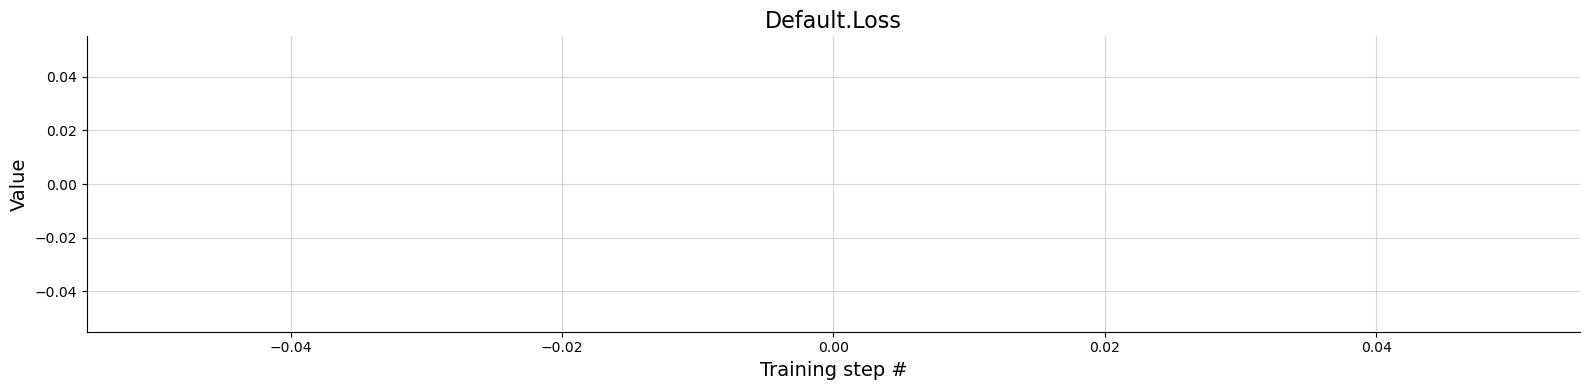

In [42]:
f = bf.diagnostics.plot_losses(history)